<a href="https://colab.research.google.com/github/Faitz761/Tugas-Pengolahan-Citra-Digital/blob/main/PCD_minggu_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

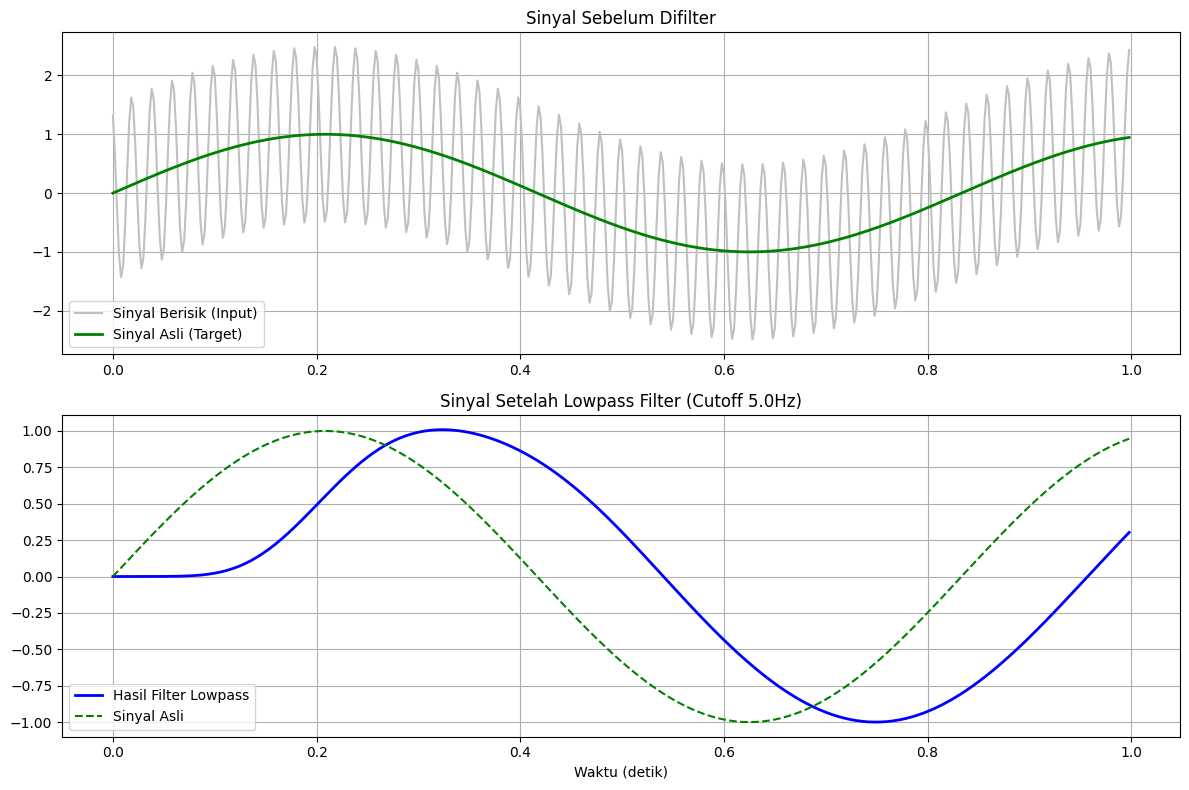

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# 1. Fungsi untuk membuat filter lowpass
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs  # Frekuensi Nyquist
    normal_cutoff = cutoff / nyq
    # Mendapatkan koefisien filter
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = lfilter(b, a, data)
    return y

# 2. Parameter Sinyal
fs = 500.0       # Frekuensi sampling (Hz)
cutoff = 5.0     # Frekuensi batas yang diinginkan (Hz)
T = 1.0          # Durasi dalam detik
n = int(T * fs)  # Jumlah sampel
t = np.linspace(0, T, n, endpoint=False)

# 3. Membuat Sinyal: Sinyal asli (rendah) + Noise (tinggi)
# Sinyal utama 1.2 Hz
sig = np.sin(1.2 * 2 * np.pi * t)
# Menambahkan noise frekuensi tinggi (50 Hz)
noise = 1.5 * np.cos(50 * 2 * np.pi * t + 0.5)
data = sig + noise

# 4. Terapkan Filter
y = butter_lowpass_filter(data, cutoff, fs, order=6)

# 5. Visualisasi Hasil
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, data, color='silver', label='Sinyal Berisik (Input)')
plt.plot(t, sig, 'g-', linewidth=2, label='Sinyal Asli (Target)')
plt.title("Sinyal Sebelum Difilter")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, y, 'b-', linewidth=2, label='Hasil Filter Lowpass')
plt.plot(t, sig, 'g--', linewidth=1.5, label='Sinyal Asli')
plt.title(f"Sinyal Setelah Lowpass Filter (Cutoff {cutoff}Hz)")
plt.xlabel('Waktu (detik)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()